In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


digits = load_digits()

# convert pixels from range 0-16 to approximately 0-1.
X = (digits.data / 16.0).tolist()
y = digits.target.tolist()


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(len(X_train))
print(len(X_train[0]))
print(y_train[0])

1437
64
5


In [4]:
# 64 pixels → 32 hidden neurons → 10 output neurons
from micrograd.nn import MLP
nin = 64
nouts = [32,10]
model = MLP(64, [32,10])

In [5]:
# check if model setup is complete or not
from micrograd.model_io import save_model
from datetime import datetime

logits = model(x=X_train[0])
predicted_digit = max(range(10), key=lambda i: logits[i].data)
print("logits: ", logits)
print("predicted_digit: ", predicted_digit)
print("y_train[0]: ", y_train[0])

# also checking if model is being saved or not 
save_model(
    nin=int(nin),
    nouts_arr=nouts,
    model=model,
    filepath = f"models/model_{datetime.now().isoformat()}_digit_classifier.json",
    metadata = {
        "classes": list(range(10)),
        "image_width": 8, 
        "image_height": 8,
        "pixel_divisor": 16.0,
    },
)

logits:  [ScalarValue(data=-6.981442601447657, grad=0), ScalarValue(data=11.296757456684498, grad=0), ScalarValue(data=7.991831404862069, grad=0), ScalarValue(data=1.0082012311422859, grad=0), ScalarValue(data=-5.580073351273196, grad=0), ScalarValue(data=-2.329537902708949, grad=0), ScalarValue(data=-6.417345028804366, grad=0), ScalarValue(data=-7.235292546911435, grad=0), ScalarValue(data=13.21202088382033, grad=0), ScalarValue(data=1.3941244582466155, grad=0)]
predicted_digit:  8
y_train[0]:  5


In [6]:
def predict(model, x: list[float]) -> int:
    logits = model(x)

    return max(
        range(len(logits)),
        key=lambda index: logits[index].data,
    )

In [5]:

import random

def cross_entropy(logits, target: int):
    # Subtracting a plain numeric maximum improves stability.
    max_logit = max(logit.data for logit in logits)
    shifted = [logit - max_logit for logit in logits]

    exponentials = [logit.exp() for logit in shifted]
    denominator = sum(exponentials)

    probability_of_target = exponentials[target] / denominator

    return -probability_of_target.log()


def batch_loss(
    model,
    batch_x: list[list[float]],
    batch_y: list[int],
):
    losses = []

    for x, target in zip(batch_x, batch_y):
        logits = model(x)
        losses.append(cross_entropy(logits, target))

    return sum(losses) / len(losses)


learning_rate = 0.03
batch_size = 32
epochs = 30

training_data = list(zip(X_train, y_train))

for epoch in range(epochs):
    random.shuffle(training_data)

    epoch_loss = 0.0
    batch_count = 0

    for start in range(0, len(training_data), batch_size):
        batch = training_data[start : start + batch_size]
        batch_x = [sample[0] for sample in batch]
        batch_y = [sample[1] for sample in batch]

        # Forward pass and loss through Micrograd.
        loss = batch_loss(model, batch_x, batch_y)

        # Clear accumulated gradients.
        model.zero_grad()

        # Micrograd backpropagation.
        loss.backward()

        # Manual SGD parameter update.
        for parameter in model.parameters():
            parameter.data -= learning_rate * parameter.grad

        epoch_loss += loss.data
        batch_count += 1

    accuracy = sum(
        predict(model, x) == target
        for x, target in zip(X_test, y_test)
    ) / len(X_test)

    print(
        f"epoch={epoch + 1:02d} "
        f"loss={epoch_loss / batch_count:.4f} "
        f"test_accuracy={accuracy:.2%}"
    )

save_model(
    nin=nin,
    nouts_arr=nouts,
    model = model,
    filepath = f"released/model_{datetime.now().isoformat()}_digit_classifier.json",
    metadata = {
        "classes": list(range(10)),
        "image_width": 8,
        "image_height": 8,
        "pixel_divisor": 16.0,
    },
)

epoch=01 loss=3.3558 test_accuracy=41.39%
epoch=02 loss=1.7082 test_accuracy=55.83%
epoch=03 loss=1.1847 test_accuracy=66.39%
epoch=04 loss=0.9127 test_accuracy=71.67%
epoch=05 loss=0.7468 test_accuracy=76.39%
epoch=06 loss=0.6414 test_accuracy=81.94%
epoch=07 loss=0.5630 test_accuracy=83.06%
epoch=08 loss=0.5034 test_accuracy=84.44%
epoch=09 loss=0.4565 test_accuracy=84.72%
epoch=10 loss=0.4184 test_accuracy=87.22%
epoch=11 loss=0.3863 test_accuracy=86.67%
epoch=12 loss=0.3595 test_accuracy=87.50%
epoch=13 loss=0.3364 test_accuracy=88.61%
epoch=14 loss=0.3199 test_accuracy=88.89%
epoch=15 loss=0.2998 test_accuracy=90.56%
epoch=16 loss=0.2849 test_accuracy=90.56%
epoch=17 loss=0.2707 test_accuracy=91.11%
epoch=18 loss=0.2585 test_accuracy=90.83%
epoch=19 loss=0.2475 test_accuracy=90.56%
epoch=20 loss=0.2372 test_accuracy=92.22%
epoch=21 loss=0.2280 test_accuracy=91.67%
epoch=22 loss=0.2198 test_accuracy=91.94%
epoch=23 loss=0.2127 test_accuracy=92.50%
epoch=24 loss=0.2056 test_accuracy

In [7]:
# Lets try the trained model 
for j in range(10):
    logits = model(x=X_test[j])
    predicted_digit = max(range(10), key=lambda i: logits[i].data)
    # print("logits: ", logits)
    print("predicted_digit: ", predicted_digit, "y_train[0]: ", y_test[j])

predicted_digit:  1 y_train[0]:  5
predicted_digit:  9 y_train[0]:  2
predicted_digit:  1 y_train[0]:  8
predicted_digit:  0 y_train[0]:  1
predicted_digit:  2 y_train[0]:  7
predicted_digit:  8 y_train[0]:  2
predicted_digit:  0 y_train[0]:  6
predicted_digit:  8 y_train[0]:  2
predicted_digit:  0 y_train[0]:  6
predicted_digit:  8 y_train[0]:  5


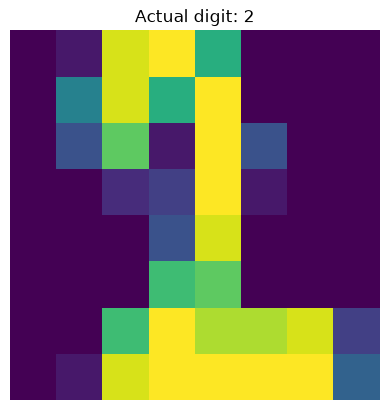

In [8]:
import matplotlib.pyplot as plt
images = digits.images

index = 1111
selected_image = images[index]
label_y_value = y[index]

plt.imshow(selected_image)
plt.title(f"Actual digit: {label_y_value}")
plt.axis("off")
plt.show()

In [9]:
# Give this image to the model 
normalized_selected_image = selected_image/16.0
flat_normalized_selected_image = [float(num) for arr in normalized_selected_image for num in arr]
print(flat_normalized_selected_image)
print(X[index])
print(f"\nflat_normalized_selected_image and its X are same or not: {flat_normalized_selected_image == X[index]}")

[0.0, 0.0625, 0.9375, 1.0, 0.625, 0.0, 0.0, 0.0, 0.0, 0.4375, 0.9375, 0.625, 1.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.75, 0.0625, 1.0, 0.25, 0.0, 0.0, 0.0, 0.0, 0.125, 0.1875, 1.0, 0.0625, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.9375, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6875, 0.75, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6875, 1.0, 0.875, 0.875, 0.9375, 0.1875, 0.0, 0.0625, 0.9375, 1.0, 1.0, 1.0, 1.0, 0.3125]
[0.0, 0.0625, 0.9375, 1.0, 0.625, 0.0, 0.0, 0.0, 0.0, 0.4375, 0.9375, 0.625, 1.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.75, 0.0625, 1.0, 0.25, 0.0, 0.0, 0.0, 0.0, 0.125, 0.1875, 1.0, 0.0625, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.9375, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6875, 0.75, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6875, 1.0, 0.875, 0.875, 0.9375, 0.1875, 0.0, 0.0625, 0.9375, 1.0, 1.0, 1.0, 1.0, 0.3125]

flat_normalized_selected_image and its X are same or not: True


In [10]:
y_predict = predict(model=model, x=flat_normalized_selected_image)
print(f"\nWe give image of = {label_y_value}\nmodel PREDICT = {y_predict}")


We give image of = 2
model PREDICT = 8


In [13]:
# Try loading saved model
from micrograd.model_io import load_model

saved_model, metadata = load_model(filepath="./released/model_2026-08-06T16:48:23.036021_digit_classifier.json")

saved_model_y_predict = predict(model=saved_model, x=flat_normalized_selected_image)

print(f"\nWe give image of = {label_y_value}\n saved model PREDICT = {saved_model_y_predict}")



We give image of = 2
 saved model PREDICT = 2
